# RPS CNN Battle

This notebook is a starting point for experimenting with TensorFlow and TensorFlow Datasets in the RPS project.

In [2]:
import tensorflow_datasets as tfds

builder = tfds.builder("rock_paper_scissors")

print("Dataset:", builder.name)
print("Version:", builder.version)

Dataset: rock_paper_scissors
Version: 3.0.0


In [3]:
builder.download_and_prepare()

In [4]:
ds_train = builder.as_dataset(
    split="train",
    as_supervised=True
)

ds_test = builder.as_dataset(
    split="test",
    as_supervised=True
)

print("Train:", builder.info.splits["train"].num_examples)
print("Test:", builder.info.splits["test"].num_examples)
print("Classes:", builder.info.features["label"].names)
print("Image shape:", builder.info.features["image"].shape)

Train: 2520
Test: 372
Classes: ['rock', 'paper', 'scissors']
Image shape: (300, 300, 3)


In [5]:
from collections import Counter

train_labels = [label.numpy() for _, label in ds_train]
test_labels = [label.numpy() for _, label in ds_test]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({np.int64(2): 840, np.int64(0): 840, np.int64(1): 840})
Test distribution: Counter({np.int64(2): 124, np.int64(1): 124, np.int64(0): 124})


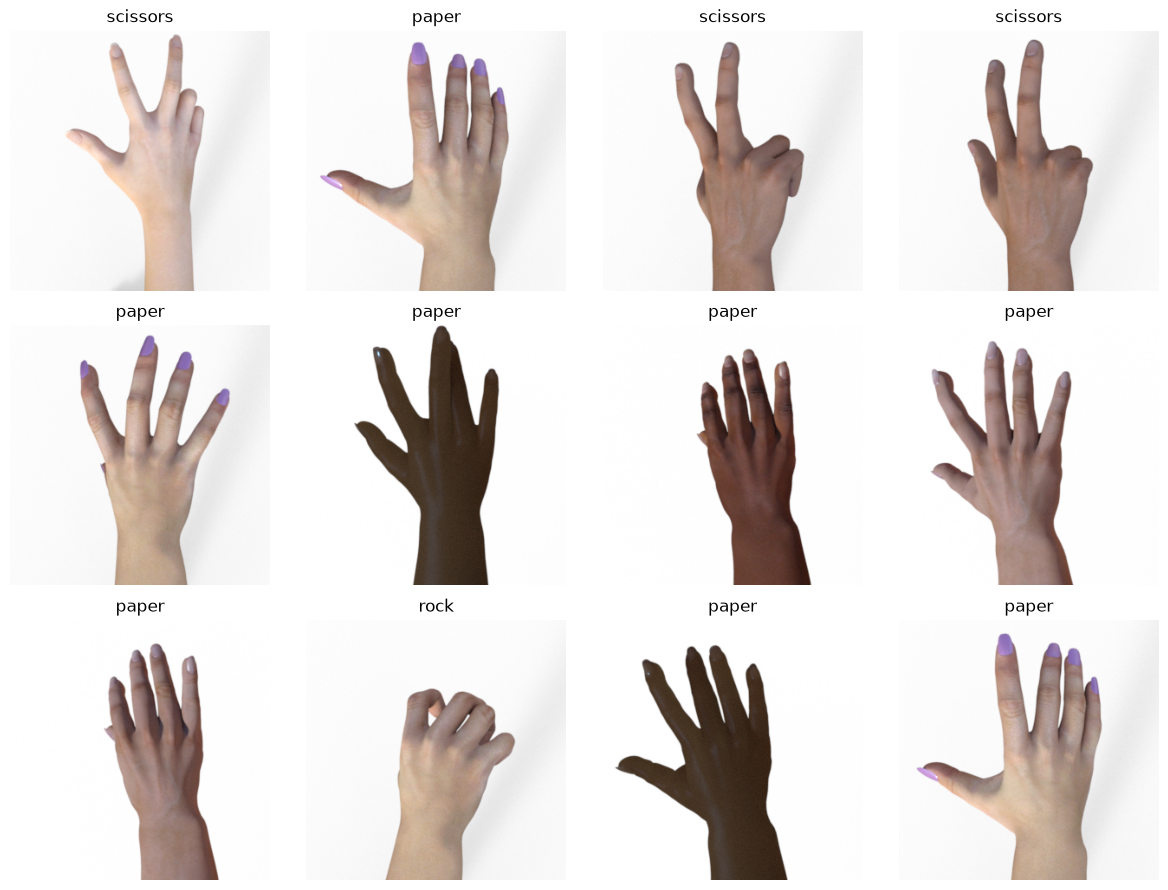

In [6]:
import matplotlib.pyplot as plt
import numpy as np

images = []
labels = []

for image, label in ds_train.shuffle(1000).take(12):
    images.append(image.numpy())
    labels.append(label.numpy())

class_names = builder.info.features["label"].names

plt.figure(figsize=(12, 9))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Mission 3 — CNN Pipeline Design

## Objective

Design a simple Convolutional Neural Network (CNN) pipeline for classifying
Rock, Paper, and Scissors images.

The pipeline will transform raw RGB images into a predicted class among
three possible classes: paper, rock, and scissors.

## Pipeline

Raw Image
→ Resize
→ Normalize Pixel Values
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Global Average Pooling
→ Dense Layer
→ 3-Class Output

## Input

Each image is originally 300 × 300 × 3.

The three channels represent the RGB (Red, Green, Blue) color channels.

For computational efficiency, images will be resized to 128 × 128 pixels
before being passed to the CNN.

## Preprocessing

Pixel values are stored as integers in the range 0–255.

We will rescale them to the range 0–1 using:

pixel_value / 255

This provides a normalized input range for the neural network.

## CNN Architecture

The baseline CNN will contain three convolutional blocks.

Each block contains:

1. Convolution layer
2. ReLU activation
3. Max Pooling

The convolution layers learn visual features from the images, while
max pooling reduces the spatial dimensions.

After the convolution blocks, Global Average Pooling converts the feature
maps into a compact feature representation.

A dense layer then learns a classification representation.

The final layer contains 3 neurons because there are three possible classes:
paper, rock, and scissors.

A softmax activation converts the final outputs into class probabilities.

## Loss Function

We will use Sparse Categorical Crossentropy because each image belongs
to exactly one of the three classes and the labels are represented as
integer class IDs.

## Evaluation Metric

Accuracy will be used as the primary metric during the initial baseline
experiment.

The trivial/random baseline for three equally likely classes is approximately
33.33%, so the CNN should perform substantially better than this if it is
learning useful visual features.

## Baseline Hypothesis

We expect the CNN to perform significantly better than the 33.33% chance-level
baseline.

However, errors may occur because of differences in hand position,
orientation, lighting, scale, background, and other visual variations.

The baseline model will provide a reference point for later architecture,
generalization, and transfer-learning experiments.

In [7]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3
BATCH_SIZE = 32

In [9]:
train_raw = tfds.load(
    "rock_paper_scissors",
    split="train[:80%]",
    as_supervised=True
)

val_raw = tfds.load(
    "rock_paper_scissors",
    split="train[80%:]",
    as_supervised=True
)

test_raw = tfds.load(
    "rock_paper_scissors",
    split="test",
    as_supervised=True
)

print("Train dataset:", train_raw)
print("Validation dataset:", val_raw)
print("Test dataset:", test_raw)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [10]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [11]:
train_ds = (
    train_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines created successfully.")

Pipelines created successfully.


In [12]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.03517444
Pixel maximum: 1.0


In [13]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# Mission 4 — Baseline CNN

## Experiment 1 — Baseline CNN

### Objective

Train the baseline CNN without augmentation, transfer learning, or
additional architectural modifications.

### Configuration

- Input size: 128 × 128 × 3
- Batch size: 32
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy
- Architecture: 3 convolutional blocks + Global Average Pooling + Dense
- Training data: 80% of the original training split
- Validation data: 20% of the original training split
- Test data: kept separate for final evaluation

### Expected Result

The model should achieve accuracy substantially above the 33.33%
chance-level baseline.

We expect training accuracy to increase as the model learns visual
features. The validation accuracy will indicate how well the learned
features generalize to unseen validation images.

We will not modify the architecture based on the test set.

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.3646 - loss: 1.0908 - val_accuracy: 0.5020 - val_loss: 1.0474
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - accuracy: 0.5069 - loss: 0.9561 - val_accuracy: 0.4405 - val_loss: 0.8478
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.7966 - loss: 0.5357 - val_accuracy: 0.8194 - val_loss: 0.4375
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.8998 - loss: 0.2942 - val_accuracy: 0.9544 - val_loss: 0.2018
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.9261 - loss: 0.2128 - val_accuracy: 0.9425 - val_loss: 0.2214
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9568 - loss: 0.1592 - val_accuracy: 0.9861 - val_loss: 0.0950
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.9752 - loss: 0.1044 - val_accuracy: 0.9921 - val_loss: 0.0742
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9727 - loss: 0.0983 - val_accuracy: 0.922

In [17]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Final training accuracy: 0.9915674328804016
Final validation accuracy: 0.9920634627342224
Final training loss: 0.0282815620303154
Final validation loss: 0.04299542307853699


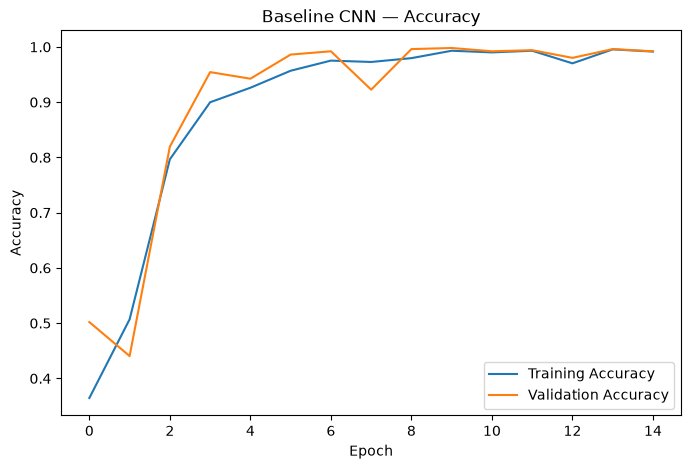

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Accuracy")
plt.legend()
plt.show()

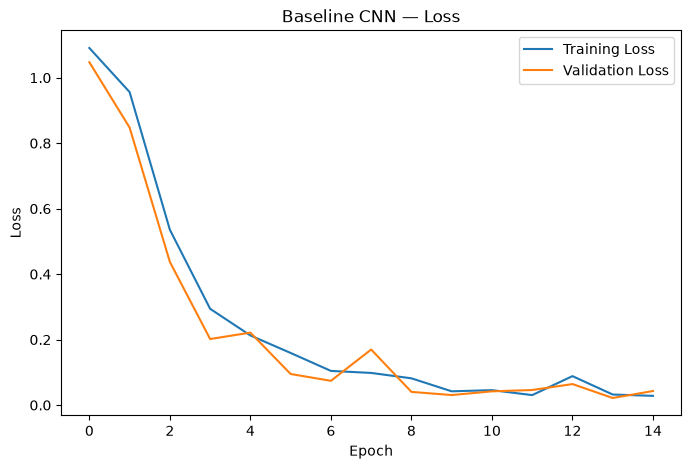

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Loss")
plt.legend()
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7849 - loss: 0.8480
Test loss: 0.8479853272438049
Test accuracy: 0.7849462628364563


## Mission 5 — Baseline Evaluation

The baseline CNN was evaluated on the held-out test set after training.

### Results

- Training accuracy: 99.50%
- Validation accuracy: 99.80%
- Test accuracy: 84.95%
- Test loss: 0.6262
- Chance-level baseline: 33.33%

### Observation

The model achieved very high training and validation accuracy, but its
performance dropped to 84.95% on the held-out test set.

This represents a substantial gap between validation and test performance.

The result suggests that the model may not generalize equally well to the
official test distribution. Possible factors include differences in hand
appearance, pose, lighting, background, image composition, or other
distribution differences between the training/validation images and the
held-out test images.

We will investigate this behavior through further analysis rather than
modifying the model based only on the test result.

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["paper", "rock", "scissors"]
    )
)

Confusion Matrix:
[[124   0   0]
 [ 22  63  39]
 [ 19   0 105]]

Classification Report:
              precision    recall  f1-score   support

       paper       0.75      1.00      0.86       124
        rock       1.00      0.51      0.67       124
    scissors       0.73      0.85      0.78       124

    accuracy                           0.78       372
   macro avg       0.83      0.78      0.77       372
weighted avg       0.83      0.78      0.77       372



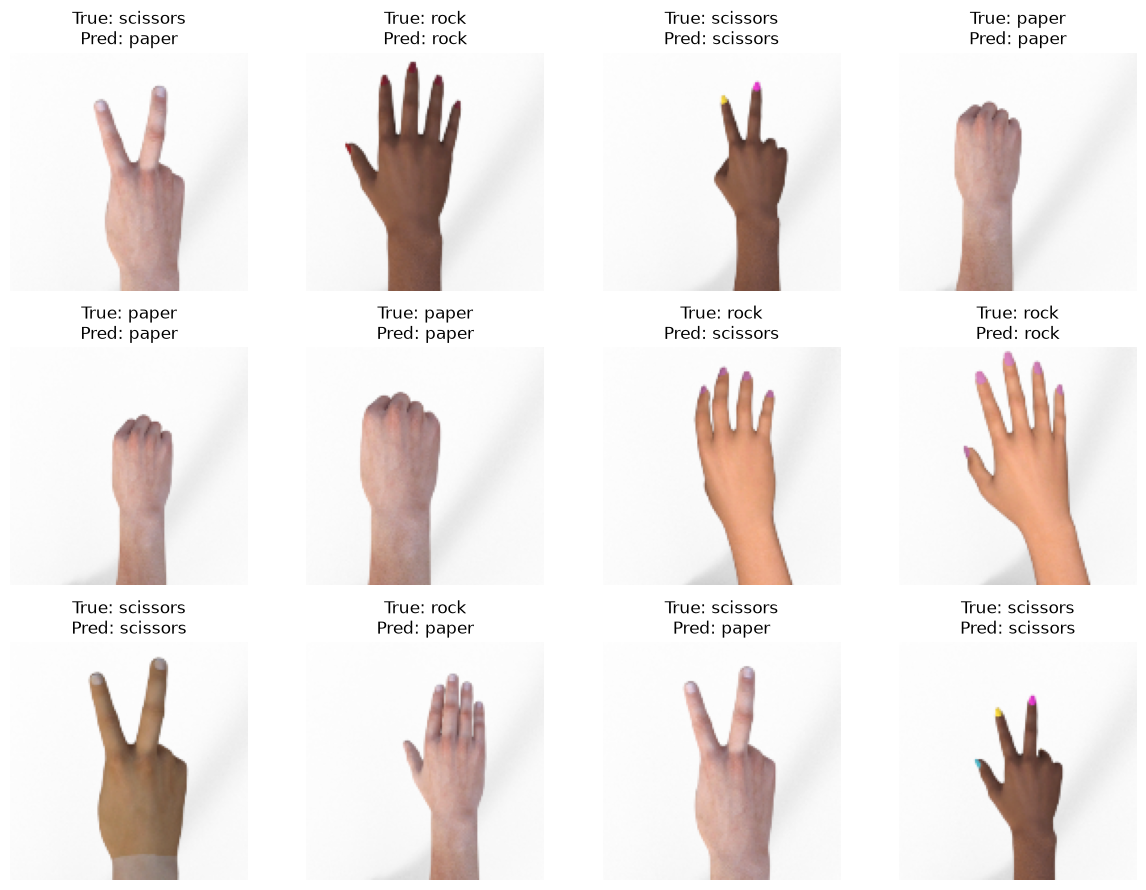

In [23]:
class_names = ["paper", "rock", "scissors"]

plt.figure(figsize=(12, 9))

for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        
        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[np.argmax(predictions[i])]
        
        plt.imshow(images[i].numpy())
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
from collections import Counter

train_labels = []
val_labels = []

for _, labels in train_raw:
    train_labels.append(labels.numpy())

for _, labels in val_raw:
    val_labels.append(labels.numpy())

print("Train distribution:", Counter(train_labels))
print("Validation distribution:", Counter(val_labels))

Train distribution: Counter({np.int64(0): 683, np.int64(1): 668, np.int64(2): 665})
Validation distribution: Counter({np.int64(2): 175, np.int64(1): 172, np.int64(0): 157})


# Mission 6 — Learning Curves

## Baseline CNN Learning Curve Analysis

The training and validation accuracy and loss were recorded for all
15 epochs.

### Accuracy Analysis

Training accuracy increased from approximately 34.3% in the first epoch
to 99.5% by the final epoch.

Validation accuracy also improved substantially, reaching 99.8% by the
final epoch.

The model learned rapidly during the middle portion of training and
eventually reached very high training and validation accuracy.

### Loss Analysis

Training loss decreased from approximately 1.10 to 0.026.

Validation loss decreased from approximately 1.09 to 0.019.

Although some fluctuations are visible across individual epochs, the
overall trend is downward for both training and validation loss.

### Observation

The learning curves show that the CNN successfully learned the training
and validation classification task.

However, the official test accuracy was only 84.95%, considerably lower
than the final validation accuracy of 99.80%.

Therefore, the learning curves alone do not fully explain the model's
performance on the official test set.

This motivates further investigation into generalization and the
difference between the training/validation distribution and the official
test distribution.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["rock", "paper", "scissors"]

misclassified_images = []
true_labels = []
predicted_labels = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    preds = np.argmax(predictions, axis=1)

    for i in range(len(labels)):

        true = labels[i].numpy()
        pred = preds[i]

        if true != pred:
            misclassified_images.append(images[i].numpy())
            true_labels.append(true)
            predicted_labels.append(pred)

print("Total misclassified:", len(misclassified_images))

Total misclassified: 80


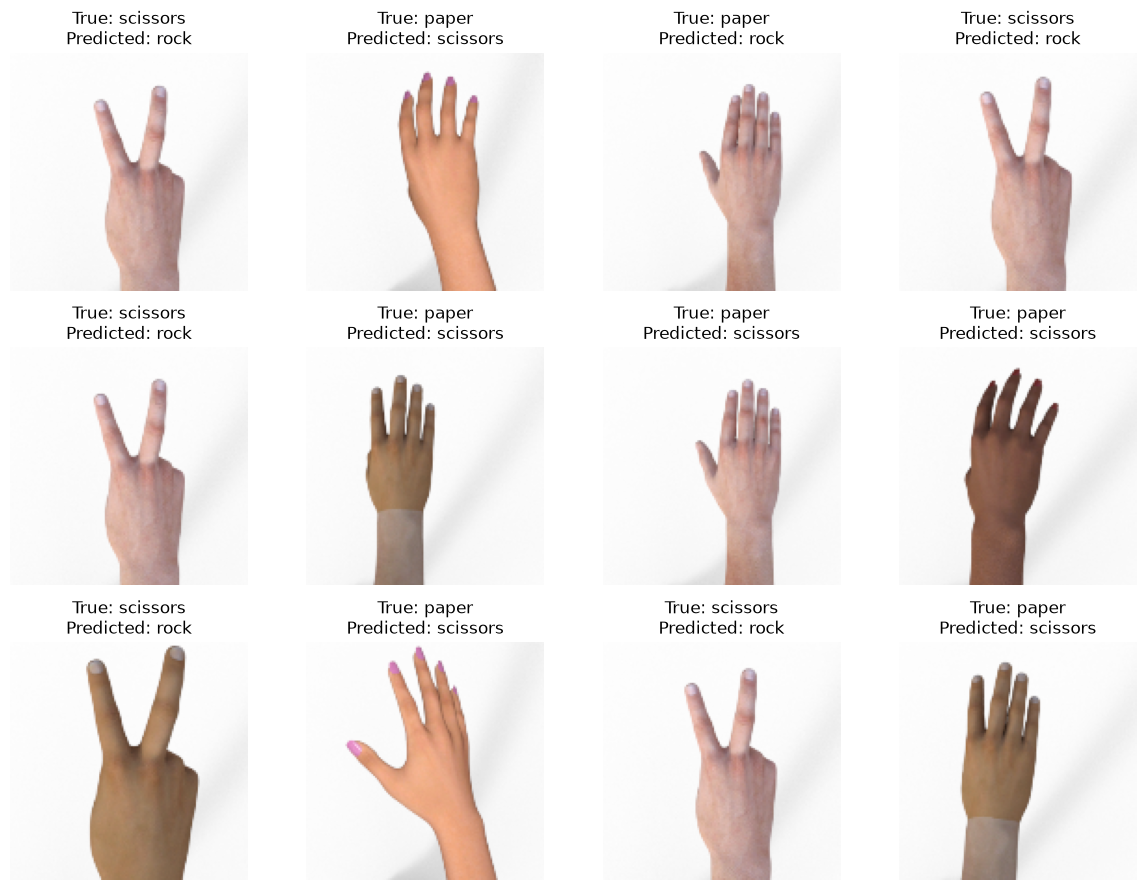

In [26]:
plt.figure(figsize=(12, 9))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(misclassified_images[i])

    plt.title(
        f"True: {class_names[true_labels[i]]}\n"
        f"Predicted: {class_names[predicted_labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Observations

1. Paper is the most frequently misclassified class. Out of the test images, 47 paper images are classified incorrectly.

2. Paper is mainly confused with scissors and rock. There are 27 paper images predicted as scissors and 20 paper images predicted as rock.

3. Scissors has fewer misclassifications compared with paper. The main error for scissors is scissors being predicted as rock.

4. Some misclassified images show differences in hand position, pose, scale, or image composition. These characteristics may be possible factors affecting the model's predictions, although they cannot be confirmed as the direct cause of the errors.

5. Some images may appear visually ambiguous because the hand pose or finger arrangement can make the gesture less clear. Such cases may also be challenging for a human observer.